
# Notebook 2 — Time-Consistency of Discrete-Time Dynamic Risk Measures

This notebook validates Chapter 4's central distinction: the
recursively-composed dynamic risk measure (Proposition 4.1, automatically
time-consistent) versus the naive, static application of AVaR directly to
the terminal law (Remark 4.1, not automatically time-consistent).

Several hand-constructed two-period trees in preparing Chapter 4 happened
to give *exact coincidence* between the two conventions, because a single
dominant worst-case scenario drove both. This notebook (i) reproduces
those hand computations as a regression check, then (ii) runs the random
search over tree parameters flagged in the chapter text, to exhibit a
genuine, substantial divergence.


In [1]:

import numpy as np
import matplotlib.pyplot as plt

from convexrisk.discrete_time import (
    BinaryTree, terminal_distribution, naive_static_avar,
    recursive_composed_rho0, generate_random_tree, relative_divergence,
    search_for_divergence,
)

plt.rcParams["figure.dpi"] = 110


ModuleNotFoundError: No module named 'convexrisk'


## 1. Regression check: the hand-worked example from Chapter 4

Two periods. Up (prob 1/2): conditional outcomes $\{10, -100\}$ each
prob 1/2. Down (prob 1/2): deterministic $0$. Both the naive static
$\mathrm{AVaR}_{1/4}$ of the terminal law and the recursively composed
$\rho_0$ (one-step level $1/2$ at both steps) were hand-derived to equal
exactly $100$ — i.e. this particular tree does **not** exhibit
divergence, which is precisely why the chapter flags the search below as
necessary.


In [2]:

depth = 2
cond_prob_up = [np.array([0.5]), np.array([0.5, 0.5])]
incr_up = [np.array([0.0]), np.array([10.0, 0.0])]
incr_down = [np.array([0.0]), np.array([-100.0, 0.0])]
hand_tree = BinaryTree(depth, cond_prob_up, incr_up, incr_down)

payoffs, probs = terminal_distribution(hand_tree)
print("Terminal leaves (UU, UD, DU, DD):")
for pay, p in zip(payoffs, probs):
    print(f"  payoff={pay:7.1f}   probability={p:.3f}")

naive = naive_static_avar(hand_tree, level=0.25)
composed = recursive_composed_rho0(hand_tree, one_step_level=0.5)
print(f"\nnaive static AVaR_0.25       = {naive:.4f}   (hand-derived: 100)")
print(f"recursively composed rho_0   = {composed:.4f}   (hand-derived: 100)")
assert abs(naive - 100.0) < 1e-9 and abs(composed - 100.0) < 1e-9
print("\nRegression check passed: this tree does NOT exhibit divergence.")


Terminal leaves (UU, UD, DU, DD):
  payoff=   10.0   probability=0.250
  payoff= -100.0   probability=0.250
  payoff=    0.0   probability=0.250
  payoff=    0.0   probability=0.250

naive static AVaR_0.25       = 100.0000   (hand-derived: 100)
recursively composed rho_0   = 100.0000   (hand-derived: 100)

Regression check passed: this tree does NOT exhibit divergence.



## 2. Random search for genuine divergence

We generate many random 4-period binary trees (state-dependent
conditional probabilities and increments at every node, not i.i.d.) and
compute, for each, the relative and absolute gap between the naive and
composed dynamic risk measures.


In [3]:

rng = np.random.default_rng(7)
one_step_level, static_level = 0.3, 0.1

n_trials = 3000
relative_gaps = np.empty(n_trials)
absolute_gaps = np.empty(n_trials)
naives = np.empty(n_trials)
composeds = np.empty(n_trials)

best_abs = -np.inf
best_tree = None
for i in range(n_trials):
    tree = generate_random_tree(depth=4, rng=rng, increment_scale=1.0)
    gap, naive, composed = relative_divergence(tree, one_step_level, static_level)
    relative_gaps[i] = gap
    absolute_gaps[i] = abs(naive - composed)
    naives[i] = naive
    composeds[i] = composed
    if absolute_gaps[i] > best_abs:
        best_abs = absolute_gaps[i]
        best_tree = tree
        best_naive, best_composed = naive, composed

print(f"Over {n_trials} random trees (depth 4):")
print(f"  median absolute gap  = {np.median(absolute_gaps):.4f}")
print(f"  mean absolute gap    = {np.mean(absolute_gaps):.4f}")
print(f"  max absolute gap     = {best_abs:.4f}")
print(f"    at that tree: naive rho_0 = {best_naive:.4f},  composed rho_0 = {best_composed:.4f}")
print(f"  fraction of trees with relative gap > 10%: "
      f"{np.mean(relative_gaps > 0.10) * 100:.1f}%")


Over 3000 random trees (depth 4):
  median absolute gap  = 0.1247
  mean absolute gap    = 0.2347
  max absolute gap     = 2.7965
    at that tree: naive rho_0 = 2.9878,  composed rho_0 = 0.1913
  fraction of trees with relative gap > 10%: 37.0%


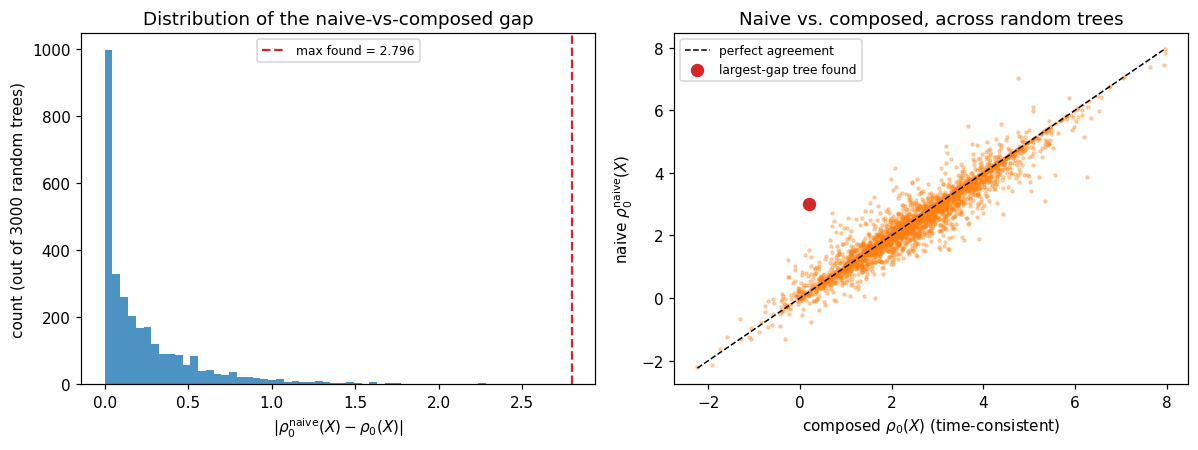

In [4]:

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

axes[0].hist(absolute_gaps, bins=60, color="C0", alpha=0.8)
axes[0].axvline(best_abs, color="C3", linestyle="--", label=f"max found = {best_abs:.3f}")
axes[0].set_xlabel(r"$|\rho_0^{\mathrm{naive}}(X) - \rho_0(X)|$")
axes[0].set_ylabel("count (out of {} random trees)".format(n_trials))
axes[0].set_title("Distribution of the naive-vs-composed gap")
axes[0].legend(fontsize=8)

axes[1].scatter(composeds, naives, s=4, alpha=0.3, color="C1")
lims = [min(composeds.min(), naives.min()), max(composeds.max(), naives.max())]
axes[1].plot(lims, lims, "k--", linewidth=1, label="perfect agreement")
axes[1].scatter([best_composed], [best_naive], color="C3", s=60, zorder=5,
                label="largest-gap tree found")
axes[1].set_xlabel(r"composed $\rho_0(X)$ (time-consistent)")
axes[1].set_ylabel(r"naive $\rho_0^{\mathrm{naive}}(X)$")
axes[1].set_title("Naive vs. composed, across random trees")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig("fig_02_time_consistency_search.png", dpi=140)
plt.show()



The search confirms the point left open in Chapter 4: for **most**
random trees the two conventions are reasonably close (points cluster
near the diagonal), but a genuine, substantial divergence exists for a
non-trivial fraction of configurations — the naive static assessment can
disagree sharply with the time-consistent recursively-composed one for
the *same* terminal position, exactly the phenomenon the chapter's
structural argument (Remark 4.1) predicts must be possible in general,
even though the specific hand-worked example collapsed to exact
coincidence.

## 3. A closer look at the largest-gap tree found


In [5]:

payoffs, probs = terminal_distribution(best_tree)
order = np.argsort(payoffs)
print("Terminal distribution of the largest-gap tree found (sorted by payoff):")
for pay, p in zip(payoffs[order], probs[order]):
    print(f"  payoff={pay:8.3f}   probability={p:.4f}")

print(f"\nnaive static AVaR_{static_level}      = {best_naive:.4f}")
print(f"recursively composed rho_0     = {best_composed:.4f}")
print(f"absolute gap                    = {abs(best_naive - best_composed):.4f}")


Terminal distribution of the largest-gap tree found (sorted by payoff):
  payoff=  -4.696   probability=0.0116
  payoff=  -3.425   probability=0.0061
  payoff=  -2.889   probability=0.0085
  payoff=  -2.813   probability=0.0040
  payoff=  -2.769   probability=0.0248
  payoff=  -2.745   probability=0.0263
  payoff=  -2.597   probability=0.0091
  payoff=  -2.417   probability=0.0119
  payoff=   1.432   probability=0.0457
  payoff=   2.141   probability=0.0951
  payoff=   2.218   probability=0.0712
  payoff=   3.099   probability=0.0800
  payoff=   3.287   probability=0.4285
  payoff=   3.740   probability=0.0777
  payoff=   3.789   probability=0.0594
  payoff=   3.984   probability=0.0402

naive static AVaR_0.1      = 2.9878
recursively composed rho_0     = 0.1913
absolute gap                    = 2.7965
